0. Importing the necessary libraries.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

0. Reading the input.

In [31]:
data = pd.read_csv('winequality-red.csv')

1. Use the "quality" column as  Y for your predicted class. (make sure Y is not added in the input features X ).

In [32]:
X = data.drop('quality', axis=1)
y = data['quality']

#print(X.head()) # to just see that quality is removed
#print(y.head()) # to see the quality

2. Show a heat map of the correlations between the features. Is it easy to draw conclusions from this heat map. 

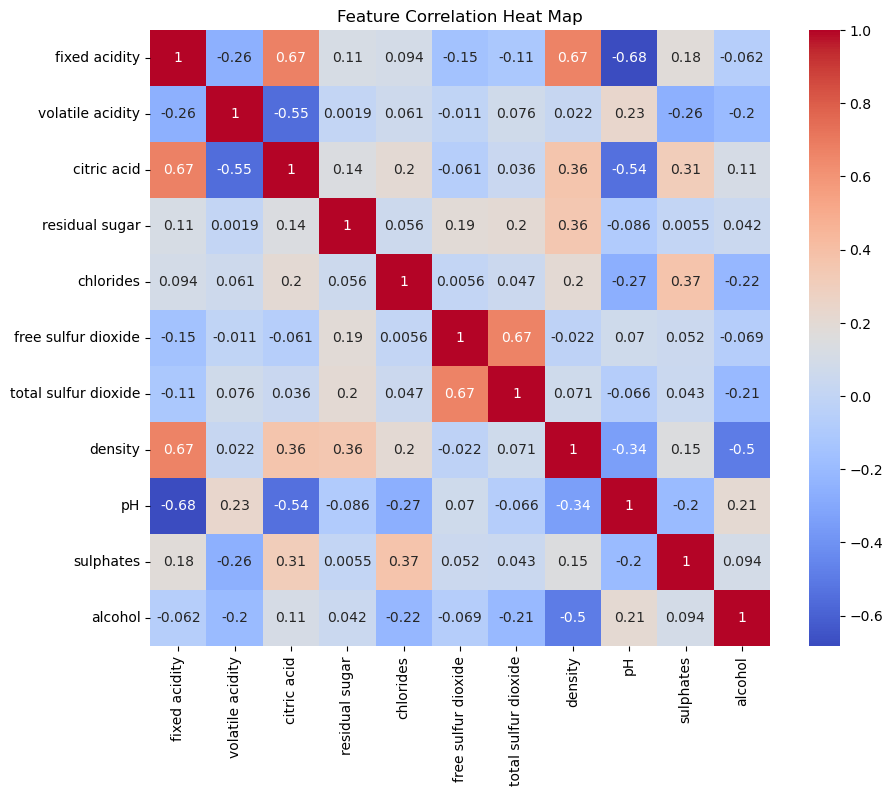

In [33]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heat Map")
plt.show()

## Observations that can be made from the heatmap:
The heatmap shows correlations among the features. While some pairs are moderately correlated, drawing clear conclusions just from this heatmap can be challenging since the relationships are not always straightforward. Some correlations may be influenced by other features, and some may be due to random chance. Also, two variables might be correlated primarily as tehy are both correlated with a third variable. Due to those reasons, it is important to use other methods to analyze the data as well.
This is the reason why we are using PCA to reduce the dimensionality of the data and then use the reduced data to train the model. HOWEVER, this is still useful method to get a geneal idea of the relationships between the features. Also, it can guide how we should select the feature selection methods.


3. Split X into a training and testing set  using 80 % for training and 20% for testing. Using random state 42.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. Transform X into a new space X'  (both training and testing) using PCA. You must standardize  before the transformation  so no feature  scale dominates the others. (So these are two steps:  StandardScaler then PCA transform) 

In [35]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_all = PCA()
X_train_pca_all = pca_all.fit_transform(X_train_scaled)

explained_variance_ratio = pca_all.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)


5. Do not set the PCA number  of components (n_componenets). Print and report the  explained variance  using 0 to all components. So  report for using 0 components then 1 component then 2 components and so on until all components have been used.  You can do this using the cumulative sum of the produced array. Report ( the variance , number of components ) plot


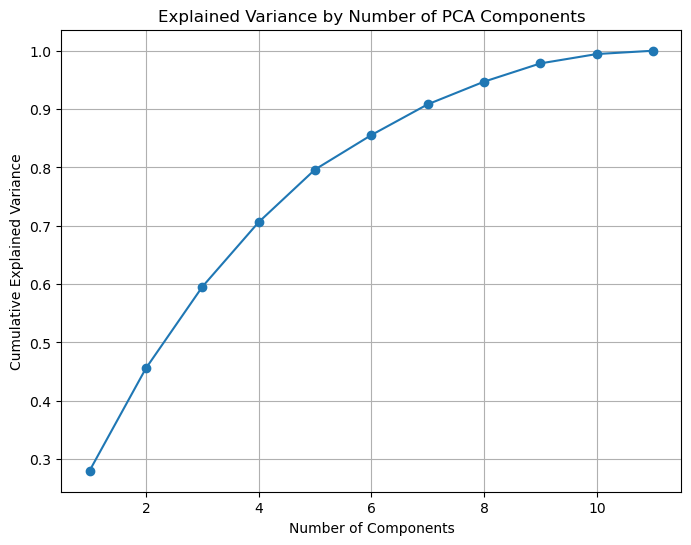

In [36]:
plt.figure(figsize=(8,6))
plt.plot(np.arange(1, len(cumulative_variance_ratio)+1), cumulative_variance_ratio, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of PCA Components')
plt.grid(True)
plt.show()

In [37]:
print("Explained Variance per Component:")
# Print for 0 components (baseline: no components used)
print(f" Component 0: Individual EV = {0.0000:.4f}, Cumulative EV = {0.0000:.4f}")

for i, (ev, cum) in enumerate(zip(explained_variance_ratio, cumulative_variance_ratio), start=1):
    print(f" Component {i}: Individual EV = {ev:.4f}, Cumulative EV = {cum:.4f}")


Explained Variance per Component:
 Component 0: Individual EV = 0.0000, Cumulative EV = 0.0000
 Component 1: Individual EV = 0.2802, Cumulative EV = 0.2802
 Component 2: Individual EV = 0.1756, Cumulative EV = 0.4558
 Component 3: Individual EV = 0.1396, Cumulative EV = 0.5954
 Component 4: Individual EV = 0.1108, Cumulative EV = 0.7062
 Component 5: Individual EV = 0.0902, Cumulative EV = 0.7964
 Component 6: Individual EV = 0.0591, Cumulative EV = 0.8555
 Component 7: Individual EV = 0.0527, Cumulative EV = 0.9082
 Component 8: Individual EV = 0.0388, Cumulative EV = 0.9470
 Component 9: Individual EV = 0.0313, Cumulative EV = 0.9783
 Component 10: Individual EV = 0.0160, Cumulative EV = 0.9943
 Component 11: Individual EV = 0.0057, Cumulative EV = 1.0000


6. Perform Linear regression to predict Y without PCA: Report (The coefficient of determination,  R2) and RMSE

In [38]:
lr_no_pca = LinearRegression()
lr_no_pca.fit(X_train_scaled, y_train)
y_pred_no_pca = lr_no_pca.predict(X_test_scaled)

r2_no_pca = lr_no_pca.score(X_test_scaled, y_test)
rmse_no_pca = np.sqrt(mean_squared_error(y_test, y_pred_no_pca))

print("\n--- Linear Regression without PCA ---")
print("Coefficient of Determination (R2):", r2_no_pca)
print("RMSE:", rmse_no_pca)


--- Linear Regression without PCA ---
Coefficient of Determination (R2): 0.4031803412796219
RMSE: 0.624519930798013


7. Perform Linear regression to predict Y with 2  PCA components : Report (The coefficient of determination,  R2) and RMSE ). How much variance do they account for.

In [39]:
def lr_with_pca(n_components):
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    lr = LinearRegression()
    lr.fit(X_train_pca, y_train)
    y_pred = lr.predict(X_test_pca)
    
    r2 = lr.score(X_test_pca, y_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    variance_explained = np.sum(pca.explained_variance_ratio_)
    return r2, rmse, variance_explained


r2_2, rmse_2, var_exp_2 = lr_with_pca(2)
print("\n--- Linear Regression with 2 PCA Components ---")
print("Coefficient of Determination (R2):", r2_2)
print("RMSE:", rmse_2)
print("Total Variance Explained by 2 Components:", var_exp_2)


--- Linear Regression with 2 PCA Components ---
Coefficient of Determination (R2): 0.16565913307829483
RMSE: 0.7384081833575191
Total Variance Explained by 2 Components: 0.4558168574104961


8.  Perform Linear regression to predict Y with 3  PCA components : Report (The coefficient of determination,  R2) and RMSE ). How much variance do they account for.

In [40]:
r2_3, rmse_3, var_exp_3 = lr_with_pca(3)
print("\n--- Linear Regression with 3 PCA Components ---")
print("Coefficient of Determination (R2):", r2_3)
print("RMSE:", rmse_3)
print("Total Variance Explained by 3 Components:", var_exp_3)


--- Linear Regression with 3 PCA Components ---
Coefficient of Determination (R2): 0.3660064768958209
RMSE: 0.6436757585573505
Total Variance Explained by 3 Components: 0.59539321545881


9. Perform Linear regression to predict Y with 4  PCA components : Report (The coefficient of determination,  R2) and RMSE ). How much variance do they account for. 

In [41]:
r2_4, rmse_4, var_exp_4 = lr_with_pca(4)
print("\n--- Linear Regression with 4 PCA Components ---")
print("Coefficient of Determination (R2):", r2_4)
print("RMSE:", rmse_4)
print("Total Variance Explained by 4 Components:", var_exp_4)


--- Linear Regression with 4 PCA Components ---
Coefficient of Determination (R2): 0.37052428325416564
RMSE: 0.6413782575264619
Total Variance Explained by 4 Components: 0.7062114399070921


10. Use cross validation  to determine the number of PCA components to use. Use the following (n_splits=10,shuffle=True,random_state=1). Plot (RSME, number of components plot).

RMSE with 5 components: 0.6671
RMSE with 10 components: 0.6564
Percent difference (5 -> 10): 1.60%


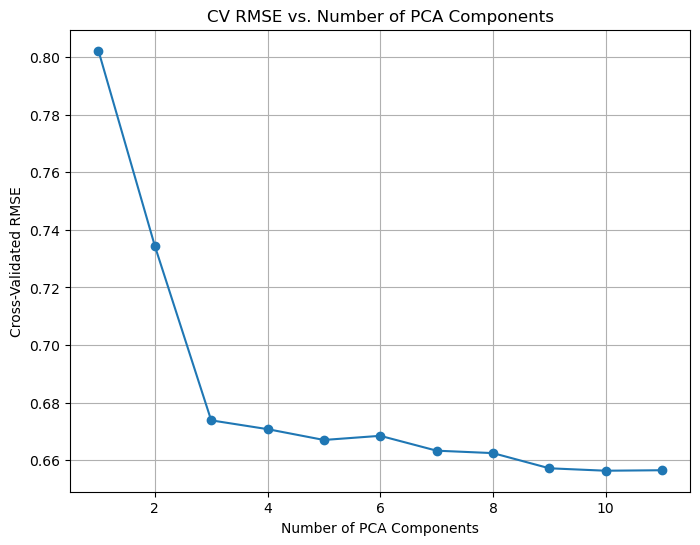

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

components_range = range(1, X_train_scaled.shape[1] + 1)
cv_rmse = []

for n in components_range:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    model = LinearRegression()
    kf = KFold(n_splits=10, shuffle=True, random_state=1)
    neg_mse_scores = cross_val_score(model, X_train_pca, y_train, 
                                     scoring='neg_mean_squared_error', cv=kf)
    mse_scores = -neg_mse_scores
    rmse = np.sqrt(mse_scores).mean()
    cv_rmse.append(rmse)
# this is just to see how many percent decrease in RMSE from 5 to 10 components
rmse_5 = cv_rmse[4]   # 5 components => index 4
rmse_10 = cv_rmse[9]  # 10 components => index 9

# Percent decrease from 5 to 10 components
percent_decrease = (rmse_5 - rmse_10) / rmse_5 * 100
print(f"RMSE with 5 components: {rmse_5:.4f}")
print(f"RMSE with 10 components: {rmse_10:.4f}")
print(f"Percent difference (5 -> 10): {percent_decrease:.2f}%")

plt.figure(figsize=(8,6))
plt.plot(list(components_range), cv_rmse, marker='o')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cross-Validated RMSE')
plt.title('CV RMSE vs. Number of PCA Components')
plt.grid(True)
plt.show()


11. Explain what is the selected component number and why? 

In [43]:
optimal_n = components_range[np.argmin(cv_rmse)]
print(f"\nOptimal number of PCA components based on CV RMSE: {optimal_n}")


Optimal number of PCA components based on CV RMSE: 10


## Why did I choose 10 components?

I chose 10 principla components as the cross validation RMSE is minimized at 10 components. This shows that using 10 components provides the best predictive performance on the test set - unseen datas. Fewer components have higher RMSE which means the model is not able to capture the variance in the data whic his worse for prediction. Adding more than 10 components won't reduce the RMSE significantly to justify added complexity due to more components. Therefore, in this case, I would choose 10 components as the optimal number of components to use for prediction. This is the best when our goal is to get the absolute best predictive performance on the test set.

However, we will consider choosing 5 components if our goal is to reduce the complexity. As you can see from the graph, the RMSE is not significantly different between 5 components and 10 components.

This is clearly shown from my code, as Percent difference (5 -> 10): 1.60% which is very low. This means that the RMSE is not significantly different between 5 and 10 components. Therefore, we can choose 5 components if we want to reduce the complexity of the model. However, if our goal is to get the best predictive performance, we should choose 10 components.